<a id="Import"></a>
# <p style="background-color: #343148FF; font-family:Pacifico; color:#ffffff; font-size:200%; font-family:Pacifico; text-align:center; border-radius:1000px 50px;">Selecting Best Model</p>

#### **Special Note : All The Given Results and Paramters are According to My Device || You Can use More Heavy Params according to You Problem and Device.**

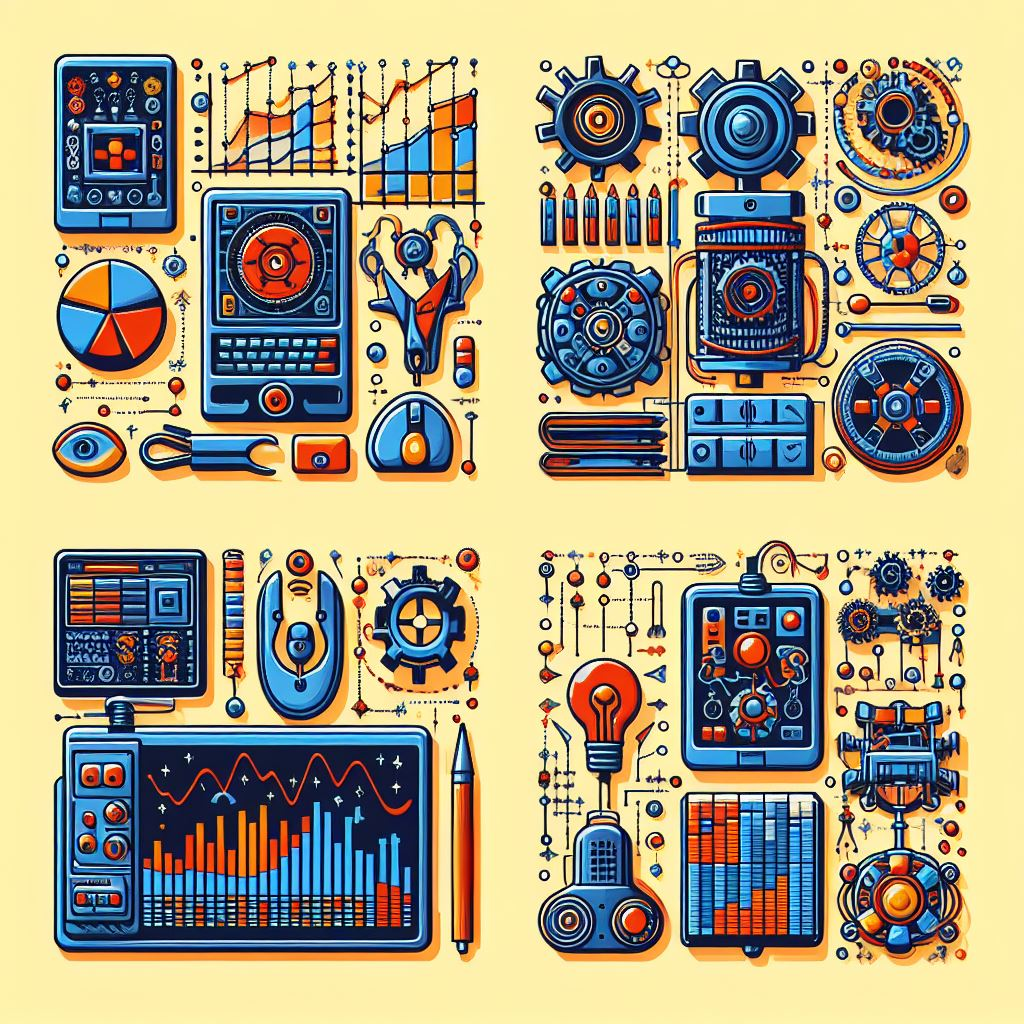

<a id="Import"></a>
# <p style="background-color: #343148FF; font-family:Pacifico; color:#ffffff; font-size:200%; font-family:Pacifico; text-align:center; border-radius:1000px 50px;">About Me</p>

<div style="border: 2px solid #DAA03DFF; padding: 10px; max-width: 1500px;">
    <p>
        I am <b>Muhammad Abdullah</b>, a passionate data scientist dedicated to mastering machine learning techniques and continually expanding my knowledge base. I believe in the mantra of #KeepLearning and #KeepSupporting, as I am committed to constant growth and uplifting others in the field.
    </p>
    <div style="text-align: center;">
        <img src="https://media.licdn.com/dms/image/D4D03AQEho5bPVChHpA/profile-displayphoto-shrink_100_100/0/1712892057663?e=1720051200&v=beta&t=9LuEqrMOFJvp8-xxHRG2SCaYpI28dUemihllpvUFZRk" alt="Profile Picture" style="width: 100px; height: 100px; border-radius: 50%; border: 2px solid #D35400;"><br>
    </div>
    <p>
        You can find more about me on my <a href="https://github.com/muhammadabdullah0303" target="_blank">GitHub</a> and <a href="https://www.linkedin.com/in/muhammad-abdullah-6b84b4297/" target="_blank">LinkedIn</a>.<br>
        Feel free to connect and reach out for any collaboration or queries!
    </p>
</div>

<a id="Import"></a>
# <p style="background-color: #343148FF; font-family:Pacifico; color:#ffffff; font-size:200%; font-family:Pacifico; text-align:center; border-radius:1000px 50px;">Basic Libraries</p>

In [ ]:
# Import Libraires 
import pandas as pd 
import numpy as np
from colorama import Fore, Style, init;
# Import necessary libraries
from IPython.display import display, HTML
import matplotlib.pyplot as plt
import seaborn as sns
# Train test Split 
from sklearn.model_selection import train_test_split
# Models 
from sklearn.naive_bayes import GaussianNB , BernoulliNB , MultinomialNB
from sklearn.tree import DecisionTreeClassifier , DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier , AdaBoostClassifier ,RandomForestRegressor , AdaBoostRegressor
from xgboost import XGBClassifier , XGBRegressor
from sklearn.linear_model import LinearRegression ,LogisticRegression
from sklearn.neighbors import KNeighborsRegressor , KNeighborsClassifier
from sklearn.ensemble import GradientBoostingRegressor , GradientBoostingClassifier
from sklearn.svm import SVC , SVR
#metrics
from sklearn.metrics import mean_squared_error , mean_absolute_error , r2_score , classification_report , accuracy_score , f1_score , precision_score
#import grid search cv for cross validation
from sklearn.model_selection import GridSearchCV , RandomizedSearchCV
# import preprocessors
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import LabelEncoder , OneHotEncoder
from sklearn.preprocessing import QuantileTransformer , PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
# Remove Warning 
import warnings
warnings.filterwarnings('ignore')
# Saving Model 
import pickle
def print_boxed_zigzag_heading(heading):
    gradient = [Fore.BLUE, Fore.CYAN, Fore.GREEN, Fore.YELLOW, Fore.RED, Fore.MAGENTA]
    print("\n" + f"{Fore.YELLOW}" + "╭" + "─" * (len(heading) + 20) + "╮" + Style.RESET_ALL)  # Change line color to yellow
    words = heading.split()
    for i, word in enumerate(words):
        if i == len(words) - 1:
            print(f"{Fore.CYAN}│ {word} │" + Style.RESET_ALL) 
        else:
            print(f"{gradient[len(word) % len(gradient)]}│ {word}", end=" ")
    print(f"{Fore.YELLOW}" + "╰" + "─" * (len(heading) + 20) + "╯" + Style.RESET_ALL) 
def print_boxed_blue_heading(heading):
    gradient = [Fore.BLUE, Fore.CYAN, Fore.GREEN, Fore.YELLOW, Fore.RED, Fore.MAGENTA]
    print("\n" + "=" * (len(heading) + 20))
    words = heading.split()
    for i, word in enumerate(words):
        if i == len(words) - 1:
            print(f"| {gradient[len(word) % len(gradient)] + word + Style.RESET_ALL} |")
        else:
            print(f"| {gradient[len(word) % len(gradient)] + word + Style.RESET_ALL}", end=" ")
    print("=" * (len(heading) + 20))

<a id="Import"></a>
# <p style="background-color: #343148FF; font-family:Pacifico; color:#ffffff; font-size:200%; font-family:Pacifico; text-align:center; border-radius:1000px 50px;">1: Regression Models Using Hyperparametering</p>

#### - **In This Section i Will Tell You How To Select Best Regression Model.**
- **First We Load Data.**
- **Split Data into Train and Test**
- **Then we Do Tunning With GridSearchCv and RandomizedSearchCv.**

#### **Special Note : All The Given Results and Paramters are According to My Device || You Can use More Heavy Params according to You Problem and Device.**

In [ ]:
# Load Dataset 
df = pd.read_csv('/kaggle/input/tipping/tips.csv')

#Tranforming tip 
qt = QuantileTransformer(output_distribution='normal', random_state=42, n_quantiles=500)
df['tip'] = qt.fit_transform(df[['tip']])

# select features and variables
X = df.drop('tip', axis=1)
y = df['tip']

# label encode Input  variables
le = LabelEncoder()
X['sex'] = le.fit_transform(X['sex'])
X['smoker'] = le.fit_transform(X['smoker'])
X['day'] = le.fit_transform(X['day'])
X['time'] = le.fit_transform(X['time'])

# # Quantile Transform , PowerTransformer
qt = QuantileTransformer(output_distribution='normal', random_state=42, n_quantiles=500)
X['total_bill'] = qt.fit_transform(X[['total_bill']])

# split the data into train and test data with 80% training dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print_boxed_zigzag_heading('Data Loaded and Splitted')

<a id="Import"></a>
# <p style="background-color: #343148FF; font-family:Pacifico; color:#ffffff; font-size:180%; font-family:Pacifico; text-align:center; border-radius:1000px 50px;">1.1: Using RandomizedSearchCV Tunning</p>

In [ ]:
# # Create a dictionaries of list of models to evaluate performance with hyperparameters
models = { 
          'LinearRegression' : (LinearRegression(), {}),
          'SVR' : (SVR(), {'kernel': ['rbf', 'poly', 'sigmoid']}),
          'DecisionTreeRegressor' : (DecisionTreeRegressor(random_state=42), {'max_depth': [None, 5, 10]}),
          'RandomForestRegressor' : (RandomForestRegressor(random_state=42), {'n_estimators': [10, 100]}),
          'KNeighborsRegressor' : (KNeighborsRegressor(), {'n_neighbors': np.arange(3, 100, 2)}),
          'GradientBoostingRegressor' : (GradientBoostingRegressor(random_state=42),{'n_estimators': [10, 100]}),
          'XGBRegressor' : (XGBRegressor(), {'n_estimators': [10, 100]}),  
          'AdaBoostRegressor': (AdaBoostRegressor(random_state=42), {'n_estimators': [10, 100]}),        
          }
model_scores = []
# For loop to iterate over the models
for name, (model, params) in models.items():
    # create a pipline
    pipeline = RandomizedSearchCV(model, params, cv=5 , verbose=1 , n_jobs=-1)
    
    # fit the pipeline
    pipeline.fit(X_train, y_train)
    
    # make prediction from each model
    y_pred = pipeline.predict(X_test)
    # Metric
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    best_parameter = pipeline.best_params_
    model_scores.append((name,r2 , mae , mse,best_parameter))
# selecting the best model from all above models with evaluation metrics sorting method
sorted_models = sorted(model_scores, key=lambda x: x[1], reverse=False)
# Printing Each model with evaluation metrics
print_boxed_zigzag_heading('R2 Of Models')
for model in sorted_models:
    print('R_2 for', f"{model[0]} is {model[1]: .2f}")
print('\n')
print_boxed_zigzag_heading('MAE Of Models')
for model in sorted_models:
    print('MAE for', f"{model[0]} is {model[2]: .2f}")
print('\n')
print_boxed_zigzag_heading('MSE Of Models')
for model in sorted_models:
    print('MSE for', f"{model[0]} is {model[3]: .2f}")
print('\n')
# Selecting the best model based on R2
best_r2_model = max(model_scores, key=lambda x: x[1])
print_boxed_zigzag_heading(f'Best model based on R2 is {best_r2_model[0]} with R2 of {best_r2_model[1]:.2f}')
print_boxed_blue_heading(f'Best Parameters: {best_r2_model[4]}')
# Selecting the best model based on MAE
best_mae_model = min(model_scores, key=lambda x: x[2])
print_boxed_zigzag_heading(f'Best model based on MAE is {best_mae_model[0]} with MAE of {best_mae_model[2]:.2f}')
print_boxed_blue_heading(f'Best Parameters: {best_mae_model[4]}')
# Selecting the best model based on MSE 
best_mse_model = min(model_scores, key=lambda x: x[3])
print_boxed_zigzag_heading(f'Best model based on MSE is {best_mse_model[0]} with MSE of {best_mse_model[3]:.2f}')
print_boxed_blue_heading(f'Best Parameters: {best_mse_model[4]}')

<a id="Import"></a>
# <p style="background-color: #343148FF; font-family:Pacifico; color:#ffffff; font-size:180%; font-family:Pacifico; text-align:center; border-radius:1000px 50px;">1.2: Saving Best Model</p>

- Here How you Can Save your Best Model

In [ ]:
# =====================================================================================================================
# Best R2 Model
# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
best_r2_model = max(model_scores, key=lambda x: x[1])
best_model_name = best_r2_model[0]
best_model_instance = models[best_model_name][0]
print(best_model_name)
# export 
pickle.dump(best_model_instance,open('pipe.pkl','wb'))
# Load Model 
svr = pickle.load(open('pipe.pkl','rb'))
# Fit Model 
svr.fit(X_train, y_train)
# Assume user input
test_input2 = np.array([10, 1, 0, 3, 1, 1],dtype=object).reshape(1,6)
# Predicting the output
svr.predict(test_input2)

# =====================================================================================================================
# Best MAE Model
# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
best_mae_model = min(model_scores, key=lambda x: x[2])
best_model_name = best_mae_model[0]
best_model_instance = models[best_model_name][0]
print(best_model_name)
# export 
pickle.dump(best_model_instance,open('pipe.pkl','wb'))
# Load Model 
svr = pickle.load(open('pipe.pkl','rb'))
# Fit Model 
svr.fit(X_train, y_train)
# Assume user input
test_input2 = np.array([10, 1, 0, 3, 1, 1],dtype=object).reshape(1,6)
# Predicting the output
svr.predict(test_input2)

# =====================================================================================================================
# Best MSE Model
# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
best_mse_model = min(model_scores, key=lambda x: x[3])
best_model_name = best_mse_model[0]
best_model_instance = models[best_model_name][0]
print(best_model_name)
# export 
pickle.dump(best_model_instance,open('pipe.pkl','wb'))
# Load Model 
svr = pickle.load(open('pipe.pkl','rb'))
# Fit Model 
svr.fit(X_train, y_train)
# Assume user input
test_input2 = np.array([10, 1, 0, 3, 1, 1],dtype=object).reshape(1,6)
# Predicting the output
svr.predict(test_input2)

<a id="Import"></a>
# <p style="background-color: #343148FF; font-family:Pacifico; color:#ffffff; font-size:200%; font-family:Pacifico; text-align:center; border-radius:1000px 50px;">1.3: Using Grid Search CV</p>

In [ ]:
# # Create a dictionaries of list of models to evaluate performance with hyperparameters
models = { 
          'LinearRegression' : (LinearRegression(), {}),
          'SVR' : (SVR(), {'kernel': ['rbf', 'poly', 'sigmoid']}),
          'DecisionTreeRegressor' : (DecisionTreeRegressor(random_state=42), {'max_depth': [None, 5, 10]}),
          'RandomForestRegressor' : (RandomForestRegressor(random_state=42), {'n_estimators': [10, 100]}),
          'KNeighborsRegressor' : (KNeighborsRegressor(), {'n_neighbors': np.arange(3, 100, 2)}),
          'GradientBoostingRegressor' : (GradientBoostingRegressor(random_state=42),{'n_estimators': [10, 100]}),
          'XGBRegressor' : (XGBRegressor(), {'n_estimators': [10, 100]}),  
          'AdaBoostRegressor': (AdaBoostRegressor(random_state=42), {'n_estimators': [10, 100]}),        
          }

model_scores = []
# For loop to iterate over the models
for name, (model, params) in models.items():
    # create a pipline
    pipeline = GridSearchCV(model, params, cv=5 , n_jobs=-1)
    
    # fit the pipeline
    pipeline.fit(X_train, y_train)
    
    # make prediction from each model
    y_pred = pipeline.predict(X_test)
    # Metric
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    best_parameter = pipeline.best_params_
    model_scores.append((name,r2 , mae , mse,best_parameter))

# selecting the best model from all above models with evaluation metrics sorting method
sorted_models = sorted(model_scores, key=lambda x: x[1], reverse=False)

# Printing Each model with evaluation metrics
print_boxed_zigzag_heading('R2 Scores')
for model in sorted_models:
    print('R_2 for', f"{model[0]} is {model[1]: .2f}")
print('\n')
print_boxed_zigzag_heading('MAE Of Models')
for model in sorted_models:
    print('MAE for', f"{model[0]} is {model[2]: .2f}")
print('\n')
print_boxed_zigzag_heading('MSE Of Models')
for model in sorted_models:
    print('MSE for', f"{model[0]} is {model[3]: .2f}")
    
# Selecting the best model based on R2
best_r2_model = max(model_scores, key=lambda x: x[1])
print_boxed_zigzag_heading(f"Best model based on R2 is {best_r2_model[0]} with R2 of {best_r2_model[1]:.2f}")
print_boxed_blue_heading(f'Best Parameters: {best_r2_model[4]}')
# Selecting the best model based on MAE
best_mae_model = min(model_scores, key=lambda x: x[2])
print_boxed_zigzag_heading(f"Best model based on MAE is' {best_mae_model[0]} with MAE of {best_mae_model[2]:.2f}")
print_boxed_blue_heading(f'Best Parameters: {best_mae_model[4]}')
# Selecting the best model based on MSE 
best_mse_model = min(model_scores, key=lambda x: x[3])
print_boxed_zigzag_heading(f"Best model based on MSE is' {best_mse_model[0]} with MSE of {best_mse_model[3]:.2f}")
print_boxed_blue_heading(f'Best Parameters: {best_mse_model[4]}')

<a id="Import"></a>
# <p style="background-color: #343148FF; font-family:Pacifico; color:#ffffff; font-size:180%; font-family:Pacifico; text-align:center; border-radius:1000px 50px;">1.4: Saving Best Model</p>

In [ ]:
# =====================================================================================================================
# Best R2 Model
# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
best_r2_model = max(model_scores, key=lambda x: x[1])
best_model_name = best_r2_model[0]
best_model_instance = models[best_model_name][0]
print(best_model_name)
# export 
pickle.dump(best_model_instance,open('pipe.pkl','wb'))
# Load Model 
svr = pickle.load(open('pipe.pkl','rb'))
# Fit Model 
svr.fit(X_train, y_train)
# Assume user input
test_input2 = np.array([15, 1, 0, 3, 1, 1],dtype=object).reshape(1,6)
# Predicting the output
svr.predict(test_input2)

# =====================================================================================================================
# Best MAE Model
# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
best_mae_model = min(model_scores, key=lambda x: x[2])
best_model_name = best_mae_model[0]
best_model_instance = models[best_model_name][0]
print(best_model_name)
# export 
pickle.dump(best_model_instance,open('pipe.pkl','wb'))
# Load Model 
svr = pickle.load(open('pipe.pkl','rb'))
# Fit Model 
svr.fit(X_train, y_train)
# Assume user input
test_input2 = np.array([15, 1, 0, 3, 1, 1],dtype=object).reshape(1,6)
# Predicting the output
svr.predict(test_input2)

# =====================================================================================================================
# Best MSE Model
# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
best_mse_model = min(model_scores, key=lambda x: x[3])
best_model_name = best_mse_model[0]
best_model_instance = models[best_model_name][0]
print(best_model_name)
# export 
pickle.dump(best_model_instance,open('pipe.pkl','wb'))
# Load Model 
kn = pickle.load(open('pipe.pkl','rb'))
# Fit Model 
kn.fit(X_train, y_train)
# Assume user input
test_input2 = np.array([15, 1, 0, 3, 1, 1],dtype=object).reshape(1,6)
# Predicting the output
kn.predict(test_input2)

<a id="Import"></a>
# <p style="background-color: #343148FF; font-family:Pacifico; color:#ffffff; font-size:200%; font-family:Pacifico; text-align:center; border-radius:1000px 50px;">2. Best Classifier Using HyperParamterting</p>

#### - **In This Section i Will Tell You How To Select Best Regression Model.**
- **First We Load Data.**
- **Split Data into Train and Test**
- **Then we Do Tunning With GridSearchCv and RandomizedSearchCv.**

#### **Special Note : All The Given Results and Paramters are According to My Device || You Can use More Heavy Params according to You Problem and Device.**

In [ ]:
# Load Data
df = pd.read_csv('/kaggle/input/diamonds/diamonds.csv')
df = df.sample(2000 , random_state=42)
df.drop(columns=['Unnamed: 0'],inplace=True)
# select features and variables
X = df.drop('cut', axis=1)
y = df['cut']

# label encode categorical variables
le = LabelEncoder()
X['color'] = le.fit_transform(X['color'])
X['clarity'] = le.fit_transform(X['clarity'])
# encode y 
le = LabelEncoder()
y = le.fit_transform(y)
# split the data into train and test data with 80% training dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

<a id="Import"></a>
# <p style="background-color: #343148FF; font-family:Pacifico; color:#ffffff; font-size:180%; font-family:Pacifico; text-align:center; border-radius:1000px 50px;">2.1 Using Randomized SearchCV</p>

In [ ]:
%%time
# # Create a dictionaries of list of models to evaluate performance with hyperparameters
models = { 
          'LogicRegression' : (LogisticRegression(), {}),
          'SVC' : (SVC(), {'kernel': ['rbf', 'poly', 'sigmoid']}),
          'DesicionTreeClassifier' : (DecisionTreeClassifier(random_state=42), {'max_depth': [None, 5, 10],'random_state': [42]}),
          'RandomForestClassifier' : (RandomForestClassifier(random_state=42), {'n_estimators': [10, 100],'random_state': [42],'max_depth': [None, 5, 10]}),
          'KNeighborsClassifier' : (KNeighborsClassifier(), {'n_neighbors': np.arange(3, 100, 2),}),
          'GradientBoostingClassifier' : (GradientBoostingClassifier(random_state=42),{'n_estimators': [10, 100],'random_state': [42]}),
          'XGBClassifier' : (XGBClassifier(), {'n_estimators': [10, 100]}),  
          'AdaBoostClassifier': (AdaBoostClassifier(random_state=42), {'n_estimators': [10, 100],'random_state': [42]}),
          }

# train and predict each model with evaluation metrics as well making a for loop to iterate over the models
model_scores = []
for name, (model, params) in models.items():
    # create a pipline
    pipeline =RandomizedSearchCV(model, params, cv=5)
    
    # fit the pipeline
    pipeline.fit(X_train, y_train)
    
    # make prediction from each model
    y_pred = pipeline.predict(X_test)
    # Metric
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred,average='macro')
    precision = precision_score(y_test, y_pred,average='macro')
    best_parameter = pipeline.best_params_
    # Append these in the model_scores
    model_scores.append((name,accuracy , f1 , precision,best_parameter))                                    

# selecting the best model from all above models with evaluation metrics sorting method
sorted_models = sorted(model_scores, key=lambda x: x[1])

# Printing Each model with evaluation metrics
print_boxed_zigzag_heading('Accuracy Of Models')
for model in sorted_models:
    print('Accuracy_score for', f"{model[0]} is {model[1]: .2f}")
print('\n')
print_boxed_zigzag_heading('F1 Score Of Models')
for model in sorted_models:
    print('F1_Score for', f"{model[0]} is {model[2]: .2f}")
print('\n')
print_boxed_zigzag_heading('Precision Of Models')
for model in sorted_models:
    print('Precision for', f"{model[0]} is {model[3]: .2f}")
# Selecting the best model based on MAE
best_Accuracy_model = max(model_scores, key=lambda x: x[1])
print_boxed_zigzag_heading(f"Best model based on Accuracy is {best_Accuracy_model[0]} with Accuracy of {best_Accuracy_model[1]:.2f}")

# Selecting the best model based on R2
best_f1_model = max(model_scores, key=lambda x: x[2])
print_boxed_zigzag_heading(f"Best model based on F1_Score is {best_f1_model[0]} with F1_Score of {best_f1_model[2]:.2f}")

# Selecting the best model based on MSE 
best_Precision_model = max(model_scores, key=lambda x: x[3])
print_boxed_zigzag_heading(f"Best model based on Precision is' {best_Precision_model[0]} with Precision of {best_Precision_model[3]:.2f}")

<a id="Import"></a>
# <p style="background-color: #343148FF; font-family:Pacifico; color:#ffffff; font-size:180%; font-family:Pacifico; text-align:center; border-radius:1000px 50px;">2.2 Saving Best Model</p>

In [ ]:
# Selecting Best Model based on Accuracy
best_Accuracy_model = max(model_scores, key=lambda x: x[1])
best_model_name = best_Accuracy_model[0]
best_model_instance = models[best_model_name][0]
print(best_model_name)
# export
pickle.dump(best_model_instance,open('Classifier.pkl','wb'))
# Load Model
dtc = pickle.load(open('Classifier.pkl','rb'))
# Fit Model
dtc.fit(X_train, y_train)
# Predicting the output
y_pred = dtc.predict(X_test)
# Accuracy 
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy_score for', f"{best_model_name} is {accuracy: .2f}")
# Assume user input
test_input2 = np.array([0.51,0,5,61.5,56.0,1674,5.21,5.17,3.19],dtype=object).reshape(1,9)
# Predicting the output
dtc.predict(test_input2)

# Selecting Best Model based on F!_Score
best_f1_model = max(model_scores, key=lambda x: x[2])
best_model_name = best_f1_model[0]
best_model_instance = models[best_model_name][0]
print(best_model_name)
# export
pickle.dump(best_model_instance,open('Classifier_f1.pkl','wb'))
# Load Model
dtc = pickle.load(open('Classifier_f1.pkl','rb'))
# Fit Model
dtc.fit(X_train, y_train)
# Predicting the output
y_pred = dtc.predict(X_test)
# f1 
f1 = f1_score(y_test, y_pred, average='macro')
print('f1_score for', f"{best_model_name} is {f1: .2f}")
# Assume user input
test_input2 = np.array([0.52,1,5,61.5,56.0,1000,4.21,5.17,3.19],dtype=object).reshape(1,9)
# Predicting the output
dtc.predict(test_input2)

<a id="Import"></a>
# <p style="background-color: #343148FF; font-family:Pacifico; color:#ffffff; font-size:200%; font-family:Pacifico; text-align:center; border-radius:1000px 50px;">2.3 GridSearch CV</p>

In [ ]:
%%time
# # Create a dictionaries of list of models to evaluate performance with hyperparameters
models = { 
          'LogicRegression' : (LogisticRegression(), {}),
          'SVC' : (SVC(), {'kernel': ['rbf', 'poly', 'sigmoid']}),
          'DesicionTreeClassifier' : (DecisionTreeClassifier(random_state=42), {'max_depth': [None, 5, 10],'random_state': [42]}),
          'RandomForestClassifier' : (RandomForestClassifier(random_state=42), {'n_estimators': [10, 100],'random_state': [42],'max_depth': [None, 5, 10]}),
          'KNeighborsClassifier' : (KNeighborsClassifier(), {'n_neighbors': np.arange(3, 100, 2),}),
          'GradientBoostingClassifier' : (GradientBoostingClassifier(random_state=42),{'n_estimators': [10, 100],'random_state': [42]}),
          'XGBClassifier' : (XGBClassifier(), {'n_estimators': [10, 100]}),  
          'AdaBoostClassifier': (AdaBoostClassifier(random_state=42), {'n_estimators': [10, 100],'random_state': [42]}),
          }

# train and predict each model with evaluation metrics as well making a for loop to iterate over the models
model_scores = []
for name, (model, params) in models.items():
    # create a pipline
    pipeline =GridSearchCV(model, params, cv=5)
    
    # fit the pipeline
    pipeline.fit(X_train, y_train)
    
    # make prediction from each model
    y_pred = pipeline.predict(X_test)
    # Metric
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred,average='macro')
    precision = precision_score(y_test, y_pred,average='macro')
    best_parameter = pipeline.best_params_
    # Append these in the model_scores
    model_scores.append((name,accuracy , f1 , precision,best_parameter))

# selecting the best model from all above models with evaluation metrics sorting method
sorted_models = sorted(model_scores, key=lambda x: x[1])

# Printing Each model with evaluation metrics
print_boxed_zigzag_heading('Accuracy Of Models')
for model in sorted_models:
    print('Accuracy_score for', f"{model[0]} is {model[1]: .2f}")
print('\n')
print_boxed_zigzag_heading('F1 Score Of Models')
for model in sorted_models:
    print('F1_Score for', f"{model[0]} is {model[2]: .2f}")
print('\n')
print_boxed_zigzag_heading('Precision Of Models')
for model in sorted_models:
    print('Precision for', f"{model[0]} is {model[3]: .2f}")
    
# Best Parameter for each model
for model in sorted_models:
    print('Best Parameters for', f"{model[0]} is {model[4]}")
print('\n')
# Selecting the best model based on MAE
best_Accuracy_model = max(model_scores, key=lambda x: x[1])
print_boxed_zigzag_heading(f"Best model based on Accuracy is {best_Accuracy_model[0]} with Accuracy of {best_Accuracy_model[1]:.2f}")

# Selecting the best model based on R2
best_f1_model = max(model_scores, key=lambda x: x[2])
print_boxed_zigzag_heading(f"Best model based on F1_Score is {best_f1_model[0]} with F1_Score of {best_f1_model[2]:.2f}")

# Selecting the best model based on MSE 
best_Precision_model = max(model_scores, key=lambda x: x[3])
print_boxed_zigzag_heading(f"Best model based on Precision is {best_Precision_model[0]} with Precision of {best_Precision_model[3]:.2f}")

<div style="margin: 0 auto; max-width: 800px;">
    <div style="background-image: url('https://media4.giphy.com/media/v1.Y2lkPTc5MGI3NjExNmZ2YWt2eDkyNHl1bmhxejM5enJyaXZla2k1NzF2bDFiMTZxa2dpdyZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/l4FAPaGGeB7D1LfIA/giphy.gif');
                background-size: contain; /* Changed background size */
                background-repeat: no-repeat; /* Prevent background image from repeating */
                background-position: left; /* Center the background image */
                padding: 50px;
                font-family: 'calibri', sans-serif; /* Changed font family to Roboto */
                border: 4px solid #DAA03DFF; /* Changed border color */
                border-radius: 20px;
                color: #DAA03DFF; /* Changed text color */
                text-align: right;
                box-shadow: 0px 8px 15px rgba(0, 0, 0, 0.4);
                animation: fadeIn 2s ease-in-out;">
        <h1 style="font-weight: bold; color: #DAA03DFF;">Thanks For Visiting Happle Kaggle</h1>
        <style>
            @keyframes fadeIn {
                from {
                    opacity: 0;
                }
                to {
                    opacity: 1;
                }
            }
            h1 {
                margin-top: 0;
                font-size: 48px;
                text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.6);
            }
        </style>
    </div>
</div>